# 2025년도 빅데이터와 인공지능을 활용한 시스템 강건설계 데이터 챌린지!

#### - 데이터 챌린지 목표 
: 빅데이터 핸들링 능력, 데이터 특징 추출 및 선택, 차원축소 및 시각화 수행능력 평가
#### - 제공 데이터 구성 : 센서데이터(정상/고장1/고장2 각 10개) + 기록데이터(정상/고장1/고장2 각 1개)
#### - 총 4단계의 데이터 챌린지를 수행하며, 단계별 결과가 저장된 폴더(Result)와 최종 코드파일(.ipynb)을 1개 압축파일(.zip)로 제출
#### +++ csv 데이터 읽을 때 header=None 옵션 사용필수
#### +++ csv 데이터 저장할 때 header=None, index=None 옵션 사용필수
#### +++ 해당 파일의 Help Code 활용하지 않아도 결과만 맞으면 무관

### ! 과제 수행 전 확인사항 !   
이 코드 파일과 Data, SplittedData, Result 폴더의 경로는 AI_Code/DataChallenge 폴더 안에 위치시킬 것

.

.

.

## 라이브러리 import

In [2]:
import pandas as pd
import numpy  as np
import scipy.stats as sp
import pywt
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 센서데이터, 기록데이터 보기

### - 센서데이터 :
* 정상, 고장1(Shunting Effect), 고장2(전극 비정렬) 각각 10개 센서데이터
* 전류 / 전압 / 가속도 3열로 구성(시간열 없음 주의!)
* Sampling Frequency: 12800Hz
* Sampling Time: 35초
* 데이터 1개당 12개의 용접 스폿이 포함됨

### - 기록데이터 :
* 정상, 고장1(Shunting Effect), 고장2(전극 비정렬) 각각 1개 기록데이터
* 기록데이터의 각 행: 용접 시작 시점의 인덱스 12개

### 데이터 살펴보기

In [3]:
SensorData = pd.read_csv('./Data/Normal/Data_1.csv', header = None, names = ['Current', 'Voltage', 'Acceleration']) # 센서 데이터
RecordData = pd.read_csv('./Data/Normal/RecordData.csv', header = None) # 기록 데이터

In [4]:
SensorData

,Current,Voltage,Acceleration
0,0.000256,-0.110187,-0.083613
1,0.000263,0.038778,-0.074989
2,0.000136,0.081950,-0.076114
3,0.000155,-0.009106,-0.087737
4,0.000207,-0.075121,-0.073115
...,...,...,...
447995,0.002858,0.012148,-0.086987
447996,0.002779,0.004938,-0.079113
447997,0.002906,0.010764,-0.045745
447998,0.002966,0.014146,-0.072740


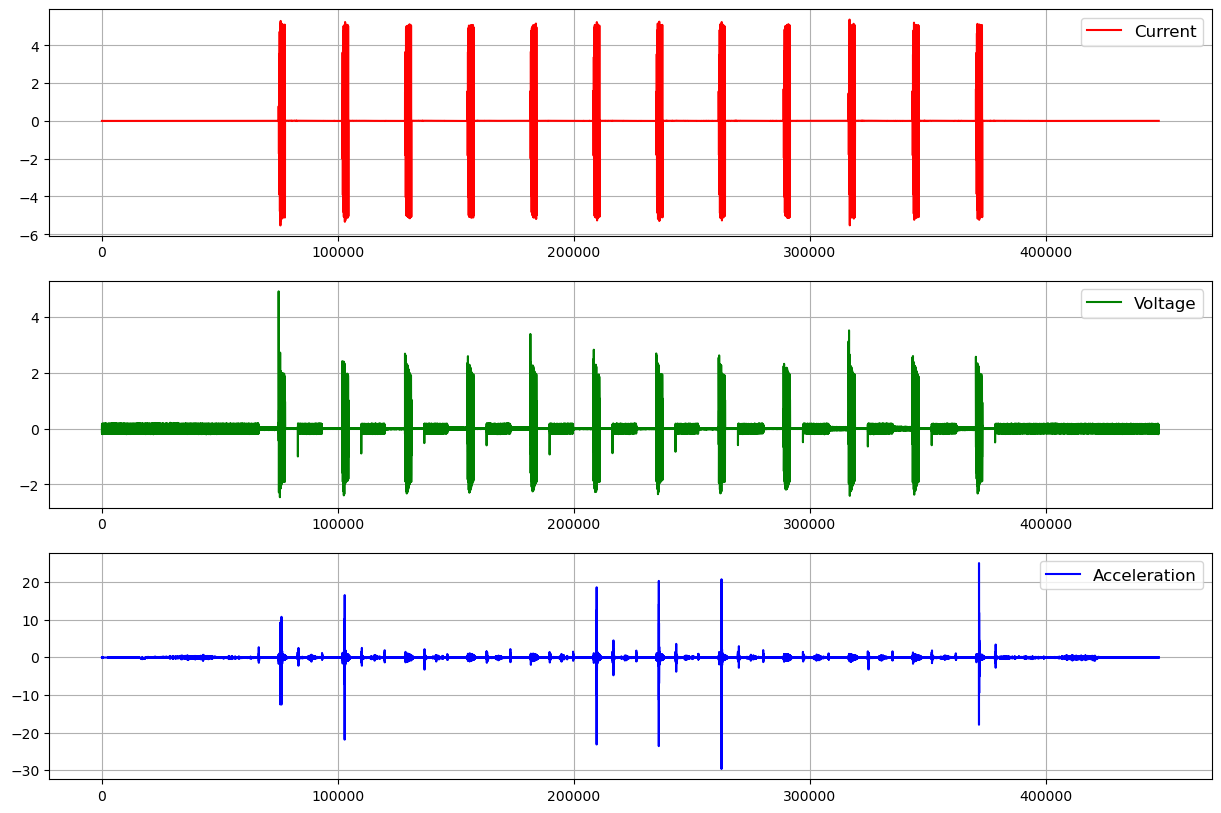

In [5]:
plt.figure(1, figsize=(15,10))
# 전류데이터 Plot
plt.subplot(3,1,1)
plt.plot(SensorData.iloc[:,0], c = 'r', label = SensorData.columns[0])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
# 전압데이터 Plot
plt.subplot(3,1,2)
plt.plot(SensorData.iloc[:,1], c = 'g', label = SensorData.columns[1])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
# 가속도데이터 Plot
plt.subplot(3,1,3)
plt.plot(SensorData.iloc[:,2], c = 'b', label = SensorData.columns[2])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
plt.show()

In [6]:
RecordData

,0,1,2,3,4,5,6,7,8,9,10,11
0,74904,101782,128458,154923,181601,208280,234958,261421,288950,316479,343583,370474
1,69471,96354,123032,149496,176174,202850,229527,255989,283517,311259,338573,365460
2,73402,100279,126740,153200,179873,206548,233223,259688,287220,314964,342067,368954
3,72413,99289,125744,152411,179075,205735,232393,258838,286351,313867,340954,368041
4,75502,102378,128835,155503,182171,208839,235721,262176,289484,317221,344318,371415
5,71015,97895,124359,151038,177929,204820,231496,257956,285270,313014,340119,367012
6,69157,96036,122496,148951,175617,202496,229165,255623,283149,310889,338199,365294
7,73063,99925,126584,153031,179693,206568,233228,259675,287191,314921,342013,369107
8,69916,96776,123221,149881,176542,203204,230079,256528,283831,311561,338651,365741
9,68888,95753,122201,148864,175528,202405,229068,255516,282818,310548,337639,364728


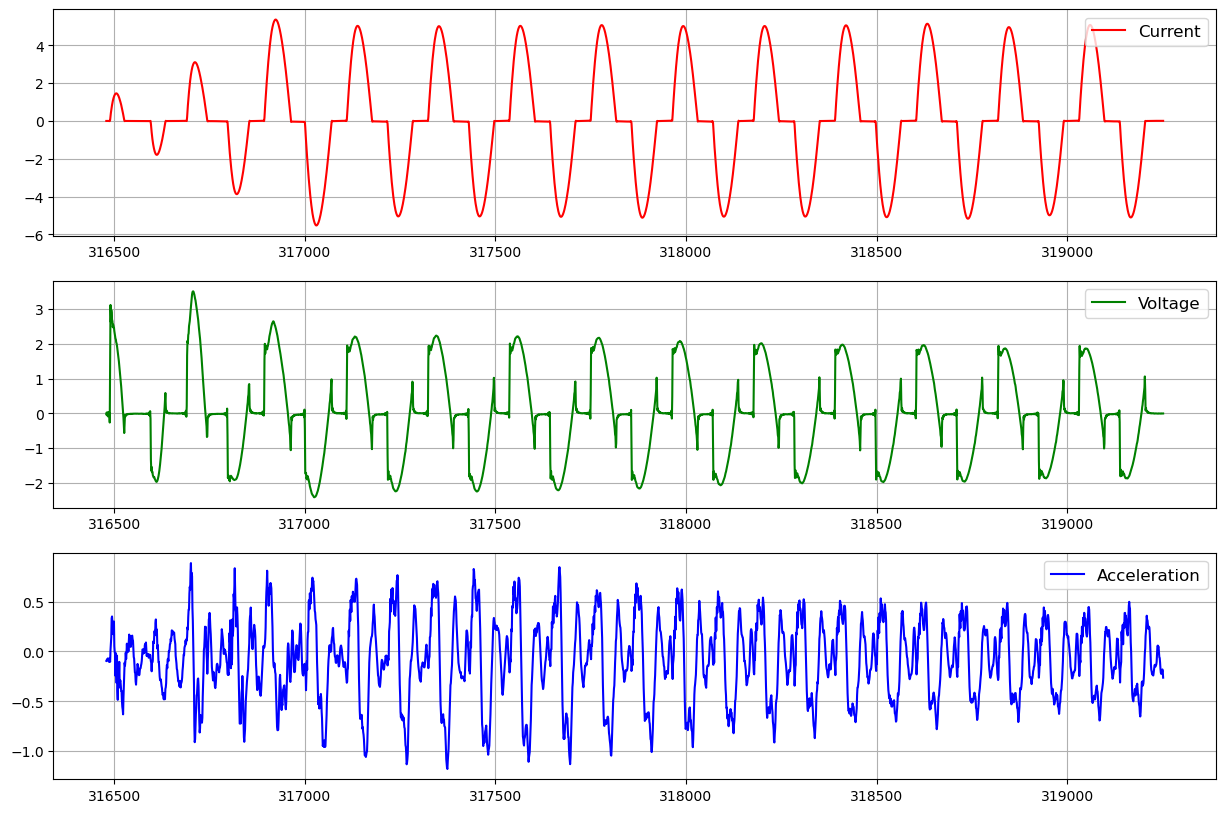

In [7]:
# 정상 스폿용접 센서 데이터 보기
DataNo = 1   # 1~10
SpotNo = 10  # 1~12

SensorData = pd.read_csv('./Data/Normal/Data_%d.csv'%DataNo, header = None, names = ['Current', 'Voltage', 'Acceleration']) # 센서 데이터

start_index = RecordData.iloc[DataNo - 1, SpotNo - 1]
SensorData_spot = SensorData.iloc[start_index:start_index+2774, :]

plt.figure(1, figsize=(15,10))
# 전류데이터 Plot
plt.subplot(3,1,1)
plt.plot(SensorData_spot.iloc[:,0], c = 'r', label = SensorData_spot.columns[0])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
# 전압데이터 Plot
plt.subplot(3,1,2)
plt.plot(SensorData_spot.iloc[:,1], c = 'g', label = SensorData_spot.columns[1])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
# 가속도데이터 Plot
plt.subplot(3,1,3)
plt.plot(SensorData_spot.iloc[:,2], c = 'b', label = SensorData_spot.columns[2])
plt.legend(loc = 'upper right', fontsize = 12)
plt.grid()
plt.show()

.

.

.

# [1단계] 센서데이터 분할
> #### 기록데이터 상 각각의 용접 시작 시점부터 2774행만큼(≒0.2167초간) 해당 센서데이터 Spot별로 분할, 저장
> #### 저장 경로 : 이 코드 파일이 위치한 경로의 ' SplittedData' 폴더 내부

## 필수!

#### SplittedData 폴더 내부 각 데이터 파일명:
* 정상(Normal) : Normal_1.csv, Normal_2.csv, Normal_3.csv, ..., Normal_120.csv
* 고장1(Fault Mode 1) : Abnormal1_1.csv, Abnormal1_2.csv, Abnormal1_3.csv, ..., Abnormal1_120.csv
* 고장2(Fault Mode 2) : Abnormal2_1.csv, Abnormal2_2.csv, Abnormal2_3.csv, ..., Abnormal2_120.csv

In [8]:
# Guide Code : 활용하지 않아도 결과만 맞으면 무관

NoOfData = 10
NoOfSpot = 12

RecordData_Normal    = pd.read_csv('./Data/Normal/RecordData.csv'   , header = None) # 정상  기록데이터 불러오기
RecordData_Abnormal1 = pd.read_csv('./Data/Abnormal1/RecordData.csv', header = None) # 고장1 기록데이터 불러오기
RecordData_Abnormal2 = pd.read_csv('./Data/Abnormal2/RecordData.csv', header = None) # 고장2 기록데이터 불러오기

for i in range(NoOfData):
    temp_path1 = './Data/Normal/Data_%d.csv'%(i+1)     # 정상  데이터 불러오기
    temp_path2 = './Data/Abnormal1/Data_%d.csv'%(i+1)  # 고장1 데이터 불러오기
    temp_path3 = './Data/Abnormal2/Data_%d.csv'%(i+1)  # 고장2 데이터 불러오기

# 센서 데이터 불러오기
    SensorData_Normal = pd.read_csv(temp_path1, header=None)
    SensorData_Abnormal1 = pd.read_csv(temp_path2, header=None)
    SensorData_Abnormal2 = pd.read_csv(temp_path3, header=None)
    
    for j in range(NoOfSpot):
        # 각 스폿의 시작 인덱스 가져오기
        start_idx_normal = RecordData_Normal.iloc[i, j]
        start_idx_abnormal1 = RecordData_Abnormal1.iloc[i, j]
        start_idx_abnormal2 = RecordData_Abnormal2.iloc[i, j]
        
        # 2774행만큼 데이터 추출
        temp_Normal = SensorData_Normal.iloc[start_idx_normal:start_idx_normal+2774, :]
        temp_Abnormal1 = SensorData_Abnormal1.iloc[start_idx_abnormal1:start_idx_abnormal1+2774, :]
        temp_Abnormal2 = SensorData_Abnormal2.iloc[start_idx_abnormal2:start_idx_abnormal2+2774, :]
        
        
        temp_Normal.to_csv('./SplittedData/Normal_%d.csv'%(i*NoOfSpot+j+1), header=None, index=None)
        temp_Abnormal1.to_csv('./SplittedData/Abnormal1_%d.csv'%(i*NoOfSpot+j+1), header=None, index=None)
        temp_Abnormal2.to_csv('./SplittedData/Abnormal2_%d.csv'%(i*NoOfSpot+j+1), header=None, index=None)

### !!! (수강생 번호 외 코드 수정 X) 1단계 결과물을 제출용 파일로 저장

In [9]:
StudentNo = 350   # 수강생 번호 입력


Step1File1 = pd.read_csv('./SplittedData/Normal_120.csv', header=None)
Step1File2 = pd.read_csv('./SplittedData/Abnormal1_120.csv', header=None)
Step1File3 = pd.read_csv('./SplittedData/Abnormal2_120.csv', header=None)

Path1 = './Result/ST%d_DC1_1.csv'%StudentNo
Path2 = './Result/ST%d_DC1_2.csv'%StudentNo
Path3 = './Result/ST%d_DC1_3.csv'%StudentNo

Step1File1.to_csv(Path1, header=None, index=None)
Step1File2.to_csv(Path2, header=None, index=None)
Step1File3.to_csv(Path3, header=None, index=None)

.

.

.

# [2단계] Time, Frequency domain 특징 추출

> ### 1단계에서 분할한 데이터들을 대상으로 정상/고장1/고장2 데이터들을 모두 불러와서 특징 추출하기 

## 필수!
* 특징값 종류 및 순서(실습코드와 동일) : Max, Min, Mean, RMS, Variance, Skewness, Kurtosis, Crest factor, Shape factor, Impulse factor
* 웨이블릿 분해 : MotherWavelet = haar, Level = 8로 설정
* 데이터당 시간 영역 특징 30개, 주파수 영역(웨이블릿 분해) 특징 240개 추출 => 전체 특징데이터 Shape (270, 360)
* 추출한 특징데이터(DataFrame) 변수명: FeatureData

In [10]:
NoOfData    = 120  # 정상/고장1/고장2 스폿용접 데이터 각 120개씩 
NoOfSensor  = 3    # 전류(Current), 전압(Voltage), 가속도(Acceleration)
NoOfFeature = 10   # 특징 개수:10개 (순서: Max, Min, Mean, RMS, Variance, Skewness, Kurtosis, Crest factor, Shape factor, Impulse factor)

#### 특징 추출(Time domain)

In [11]:
def rms(x): # RMS 함수 정의
    return np.sqrt(np.mean(x**2))

In [12]:
# Time Domain 특징값 추출

# 특징데이터 크기 지정
TimeFeature_Normal = np.zeros((NoOfSensor*NoOfFeature , NoOfData))
TimeFeature_Abnormal1 = np.zeros((NoOfSensor*NoOfFeature , NoOfData))
TimeFeature_Abnormal2 = np.zeros((NoOfSensor*NoOfFeature , NoOfData))

for i in range(NoOfData):
    
    # 데이터 불러오기
    temp_path1 = './SplittedData/Normal_%d.csv'%(i+1)      # 정상 데이터 파일 경로
    temp_path2 = './SplittedData/Abnormal1_%d.csv'%(i+1)   # 고장1 데이터 파일 경로
    temp_path3 = './SplittedData/Abnormal2_%d.csv'%(i+1)   # 고장2 데이터 파일 경로
    
    
    temp_data1 = pd.read_csv(temp_path1, header=None).values
    temp_data2 = pd.read_csv(temp_path2, header=None).values
    temp_data3 = pd.read_csv(temp_path3, header=None).values
    
    for j in range(NoOfSensor):
        # 각 센서별 데이터 추출
        sensor_normal = temp_data1[:, j]
        sensor_abnormal1 = temp_data2[:, j]
        sensor_abnormal2 = temp_data3[:, j]
        
        # Normal 특징 추출
        TimeFeature_Normal[j*NoOfFeature+0, i] = np.max(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+1, i] = np.min(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+2, i] = np.mean(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+3, i] = rms(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+4, i] = np.var(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+5, i] = sp.skew(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+6, i] = sp.kurtosis(sensor_normal)
        TimeFeature_Normal[j*NoOfFeature+7, i] = np.max(np.abs(sensor_normal)) / rms(sensor_normal)  # Crest factor
        TimeFeature_Normal[j*NoOfFeature+8, i] = rms(sensor_normal) / np.mean(np.abs(sensor_normal))  # Shape factor
        TimeFeature_Normal[j*NoOfFeature+9, i] = np.max(np.abs(sensor_normal)) / np.mean(np.abs(sensor_normal))  # Impulse factor
        
        # Abnormal1 특징 추출
        TimeFeature_Abnormal1[j*NoOfFeature+0, i] = np.max(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+1, i] = np.min(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+2, i] = np.mean(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+3, i] = rms(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+4, i] = np.var(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+5, i] = sp.skew(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+6, i] = sp.kurtosis(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+7, i] = np.max(np.abs(sensor_abnormal1)) / rms(sensor_abnormal1)
        TimeFeature_Abnormal1[j*NoOfFeature+8, i] = rms(sensor_abnormal1) / np.mean(np.abs(sensor_abnormal1))
        TimeFeature_Abnormal1[j*NoOfFeature+9, i] = np.max(np.abs(sensor_abnormal1)) / np.mean(np.abs(sensor_abnormal1))
        
        # Abnormal2 특징 추출
        TimeFeature_Abnormal2[j*NoOfFeature+0, i] = np.max(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+1, i] = np.min(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+2, i] = np.mean(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+3, i] = rms(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+4, i] = np.var(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+5, i] = sp.skew(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+6, i] = sp.kurtosis(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+7, i] = np.max(np.abs(sensor_abnormal2)) / rms(sensor_abnormal2)
        TimeFeature_Abnormal2[j*NoOfFeature+8, i] = rms(sensor_abnormal2) / np.mean(np.abs(sensor_abnormal2))
        TimeFeature_Abnormal2[j*NoOfFeature+9, i] = np.max(np.abs(sensor_abnormal2)) / np.mean(np.abs(sensor_abnormal2))
        
        
        
        
        
        
        
        
        
        
        


In [13]:
# 시간영역 특징 합치기(가로 방향)

TimeFeatureAll = np.hstack([TimeFeature_Normal, TimeFeature_Abnormal1, TimeFeature_Abnormal2])
print(f"시간영역 특징 shape: {TimeFeatureAll.shape}")

시간영역 특징 shape: (30, 360)


#### 특징 추출(Frequency domain)

In [14]:
#Frequency Domain 특징값 추출 (Wavelet Transform 기반)
# Wavelet options

MotherWavelet = pywt.Wavelet('haar')   # Mother wavelet (모함수) 지정
Level   = 8                            # Wavelet 분해 레벨 지정
select  = 8                            # 특징추출 영역 고주파 영역부터 개수 지정 (d1~)

#Frequency Domain 특징값 추출 (Wavelet Transform 기반)
FreqFeature_Normal    = np.zeros(shape=(NoOfSensor*NoOfFeature*select , NoOfData))
FreqFeature_Abnormal1 = np.zeros(shape=(NoOfSensor*NoOfFeature*select , NoOfData))
FreqFeature_Abnormal2 = np.zeros(shape=(NoOfSensor*NoOfFeature*select , NoOfData))

for i in range(NoOfData):
    
    # 데이터 불러오기
    temp_path1 = './SplittedData/Normal_%d.csv'%(i+1)      # 정상 데이터 파일 경로
    temp_path2 = './SplittedData/Abnormal1_%d.csv'%(i+1)   # 고장1 데이터 파일 경로
    temp_path3 = './SplittedData/Abnormal2_%d.csv'%(i+1)   # 고장2 데이터 파일 경로
    
    temp_data1 = np.array(pd.read_csv(temp_path1 , sep=',', header=None)) # 정상  데이터
    temp_data2 = np.array(pd.read_csv(temp_path2 , sep=',', header=None)) # 고장1 데이터
    temp_data3 = np.array(pd.read_csv(temp_path3 , sep=',', header=None)) # 고장2 데이터
    
    
    for j in range(NoOfSensor):
        # 웨이블릿 분해
        coeffs_normal = pywt.wavedec(temp_data1[:, j], MotherWavelet, level=Level)
        coeffs_abnormal1 = pywt.wavedec(temp_data2[:, j], MotherWavelet, level=Level)
        coeffs_abnormal2 = pywt.wavedec(temp_data3[:, j], MotherWavelet, level=Level)
        
        for k in range(select):
            # 상세계수 선택 (d1~d8)
            coeff_idx = -(k+1)  # 뒤에서부터 선택
            
            # Normal
            detail_normal = coeffs_normal[coeff_idx]
            idx_base = j*NoOfFeature*select + k*NoOfFeature
            FreqFeature_Normal[idx_base+0, i] = np.max(detail_normal)
            FreqFeature_Normal[idx_base+1, i] = np.min(detail_normal)
            FreqFeature_Normal[idx_base+2, i] = np.mean(detail_normal)
            FreqFeature_Normal[idx_base+3, i] = rms(detail_normal)
            FreqFeature_Normal[idx_base+4, i] = np.var(detail_normal)
            FreqFeature_Normal[idx_base+5, i] = sp.skew(detail_normal)
            FreqFeature_Normal[idx_base+6, i] = sp.kurtosis(detail_normal)
            FreqFeature_Normal[idx_base+7, i] = np.max(np.abs(detail_normal)) / (rms(detail_normal) + 1e-10)
            FreqFeature_Normal[idx_base+8, i] = rms(detail_normal) / (np.mean(np.abs(detail_normal)) + 1e-10)
            FreqFeature_Normal[idx_base+9, i] = np.max(np.abs(detail_normal)) / (np.mean(np.abs(detail_normal)) + 1e-10)
            
            # Abnormal1
            detail_abnormal1 = coeffs_abnormal1[coeff_idx]
            FreqFeature_Abnormal1[idx_base+0, i] = np.max(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+1, i] = np.min(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+2, i] = np.mean(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+3, i] = rms(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+4, i] = np.var(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+5, i] = sp.skew(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+6, i] = sp.kurtosis(detail_abnormal1)
            FreqFeature_Abnormal1[idx_base+7, i] = np.max(np.abs(detail_abnormal1)) / (rms(detail_abnormal1) + 1e-10)
            FreqFeature_Abnormal1[idx_base+8, i] = rms(detail_abnormal1) / (np.mean(np.abs(detail_abnormal1)) + 1e-10)
            FreqFeature_Abnormal1[idx_base+9, i] = np.max(np.abs(detail_abnormal1)) / (np.mean(np.abs(detail_abnormal1)) + 1e-10)
            
            # Abnormal2
            detail_abnormal2 = coeffs_abnormal2[coeff_idx]
            FreqFeature_Abnormal2[idx_base+0, i] = np.max(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+1, i] = np.min(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+2, i] = np.mean(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+3, i] = rms(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+4, i] = np.var(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+5, i] = sp.skew(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+6, i] = sp.kurtosis(detail_abnormal2)
            FreqFeature_Abnormal2[idx_base+7, i] = np.max(np.abs(detail_abnormal2)) / (rms(detail_abnormal2) + 1e-10)
            FreqFeature_Abnormal2[idx_base+8, i] = rms(detail_abnormal2) / (np.mean(np.abs(detail_abnormal2)) + 1e-10)
            FreqFeature_Abnormal2[idx_base+9, i] = np.max(np.abs(detail_abnormal2)) / (np.mean(np.abs(detail_abnormal2)) + 1e-10)
            
            
            
            
            
            
            
            
            
            
            
            
            

In [15]:
# 주파수영역 특징 합치기(가로 방향)

FreqFeatureAll = np.hstack([FreqFeature_Normal, FreqFeature_Abnormal1, FreqFeature_Abnormal2])
print(f"주파수영역 특징 shape: {FreqFeatureAll.shape}")

주파수영역 특징 shape: (240, 360)


In [16]:
# 시간/주파수영역 특징 합치기(세로 방향)


FeatureData = pd.DataFrame(np.vstack([TimeFeatureAll, FreqFeatureAll]))
print(f"전체 특징 데이터 shape: {FeatureData.shape}")

전체 특징 데이터 shape: (270, 360)


### 2단계 결과물 제출용 파일로 저장(수강생 번호 외 코드 수정 X)

In [17]:
StudentNo = 350   # 수강생 번호 입력

Path1 = './Result/ST%d_DC2.csv'%StudentNo
FeatureData.to_csv(Path1, header=None, index=None)

.

.

.

# [3단계] 특징 데이터 ANOVA 수행
> ### 특징 데이터 분리하여 정상/고장1/고장2 각각 ANOVA 기반 구분성 상위 10개 특징 선택
> ### ANOVA: scipy.stats 라이브러리의 f_oneway 함수 사용
> ##### (참고:https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)

## 필수!
* 정상/고장1/고장2  P value 기반 구분성 상위 10개 선택된 특징(DataFrame) 변수명 : FeatureSelected

#### 특징데이터 분리: 정상, 고장1, 고장2

In [18]:
NoOfData = int(FeatureData.shape[1]/3)
Normal_FeatureData    = FeatureData.iloc[:,:NoOfData]
Abnormal_FeatureData1 = FeatureData.iloc[:,NoOfData:NoOfData*2]
Abnormal_FeatureData2 = FeatureData.iloc[:,NoOfData*2:]

print(Normal_FeatureData.shape)
print(Abnormal_FeatureData1.shape)
print(Abnormal_FeatureData2.shape)

(270, 120)
(270, 120)
(270, 120)


#### 정상/고장1/고장2 특징 별 ANOVA 수행하여 P value 계산

In [19]:
NoOfFeature = FeatureData.shape[0] # 추출된 Feature 갯수

P_value = np.zeros((NoOfFeature , 2))

# 특징값 각각 T-검정 수행
for i in range(NoOfFeature):
    # 각 특징에 대해 ANOVA 수행
    f_stat, p_val = sp.f_oneway(Normal_FeatureData.iloc[i, :],
                                 Abnormal_FeatureData1.iloc[i, :],
                                 Abnormal_FeatureData2.iloc[i, :])
    P_value[i, 0] = i  # 특징 인덱스
    P_value[i, 1] = p_val  # P-value

P_value = pd.DataFrame(P_value)

#### P value 기준 정렬

In [20]:
P_value_Rank = P_value.sort_values(by=1, ascending=True)
P_value_Rank = P_value_Rank.reset_index(drop=True)


#### P value 기반 구분성 상위 10개 특징 선택

In [21]:
# StartRank 부터 Number 만큼의 Feature
StartRank = 1
Number = 10

SelectedFeatures = np.zeros((Number, FeatureData.shape[1]))

for idx, i in enumerate(range(StartRank-1, StartRank-1+Number)):
    feature_idx = int(P_value_Rank.iloc[i, 0])
    SelectedFeatures[idx, :] = FeatureData.iloc[feature_idx, :]

FeatureSelected = pd.DataFrame(SelectedFeatures)
print(f"선택된 특징 shape: {FeatureSelected.shape}")



선택된 특징 shape: (10, 360)


### 3단계 결과물 제출용 파일로 저장(수강생 번호 외 코드 수정 X)

In [22]:
StudentNo = 350   # 수강생 번호 입력

Path1 = './Result/ST%d_DC3.csv'%StudentNo

FeatureSelected.to_csv(Path1, header=None, index=None)

.

.

.

# [4단계] 선택된 특징 각각 차원축소(PCA) 및 2D Plot 시각화

## 필수!
* PCA 적용 전 특징 데이터 표준화 (StandardScaler 활용)
* Plot 설정 아래와 같이 수행
               figsize = (10, 10)   
               점 색깔: 정상=파랑('b'), 고장1=빨강('r'), 고장2=자홍('m')   
               Label: 정상='Normal', 고장1='Abnormal1', 고장2='Abnormal2'
               공통 옵션: linestyle='', marker='o'
               가로/세로 축 이름 각각 PC1/PC2

* 출력된 그래프를 'ST(수강생번호)_DC4.png'이름으로 Result 폴더 내 저장

In [23]:
FeatureSelected_T = FeatureSelected.T

In [24]:
# 선택된 특징데이터에 대한 표준화
scaler = StandardScaler()
FeatureSelected_normed = scaler.fit_transform(FeatureSelected_T)
print(f"표준화된 데이터 shape: {FeatureSelected_normed.shape}")

표준화된 데이터 shape: (360, 10)


#### 선정된 특징 PCA 통한 차원축소

In [25]:
# 10개 PC(Principal Component) 추출
pca = PCA(n_components = 2)
PC  = pca.fit_transform(FeatureSelected_normed)
print(f"PCA 결과 shape: {PC.shape}")

PCA 결과 shape: (360, 2)


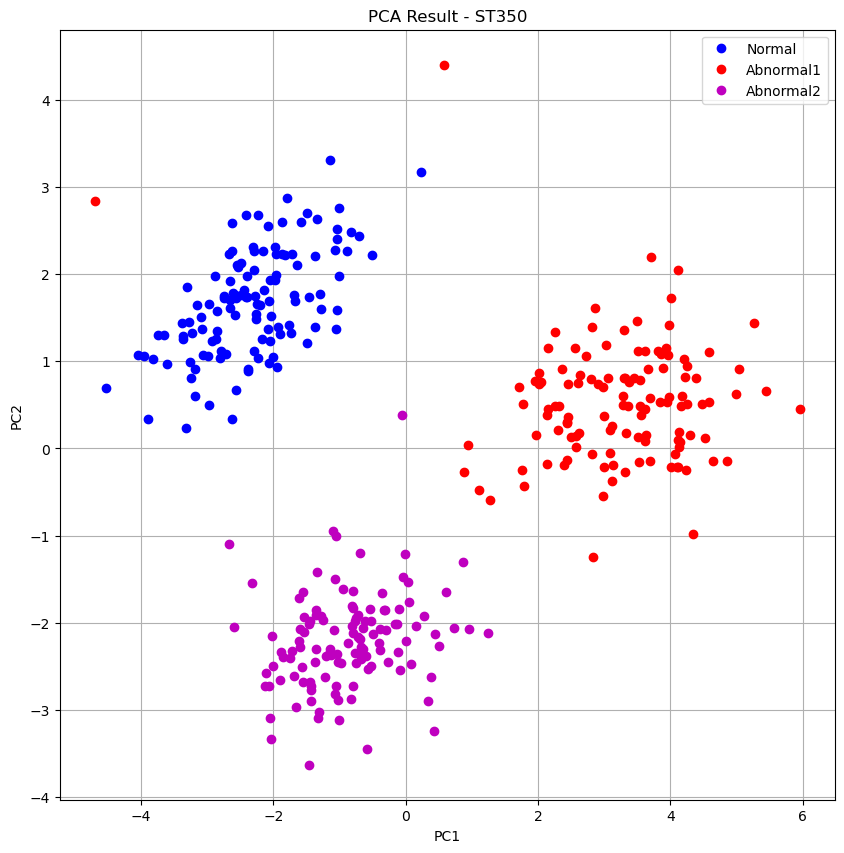

In [26]:
# PC1, PC2 2가지 주성분의 산점도 그리기

plt.figure(figsize=(10, 10))

# 데이터 분리
PC_Normal = PC[:120, :]
PC_Abnormal1 = PC[120:240, :]
PC_Abnormal2 = PC[240:, :]

# 플롯
plt.plot(PC_Normal[:, 0], PC_Normal[:, 1], 'b', linestyle='', marker='o', label='Normal')
plt.plot(PC_Abnormal1[:, 0], PC_Abnormal1[:, 1], 'r', linestyle='', marker='o', label='Abnormal1')
plt.plot(PC_Abnormal2[:, 0], PC_Abnormal2[:, 1], 'm', linestyle='', marker='o', label='Abnormal2')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.title(f'PCA Result - ST{StudentNo}')

# 그래프 저장
plt.savefig('./Result/ST%d_DC4.png'%StudentNo)
plt.show()













.

.

.

# ● 결과가 저장된 폴더(Result)와 작성 완료된 본 코드 파일을 하나의 zip파일로 제출
> ## 압축파일 이름 ST(수강생번호)_DC (예시: 'ST00_DC', 'ST0_DC')
압축파일 더블클릭시 Result 폴더, DataChallenge_ST-(수강생번호) 나타나도록 파일 구성